In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()

if (current_dir / "cartpole.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "cartpole.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find cartpole.py in the current directory or its parent."
    )

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
REPORT_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [DATA_DIR, FIGURE_DIR, NOTEBOOK_DIR, REPORT_DIR, SRC_DIR]:
    folder.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure dir:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning
Figure dir: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures


In [2]:
from cartpole import CartPole, remap_angle

STATE_NAMES = ["x", "x_dot", "theta", "theta_dot"]

STATE_LABELS = [
    "cart position x",
    "cart velocity x_dot",
    "pole angle theta",
    "pole angular velocity theta_dot",
]

DELTA_NAMES = [
    "Delta x",
    "Delta x_dot",
    "Delta theta",
    "Delta theta_dot",
]

In [3]:
def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)
    return path


def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)


def mse_per_dimension(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2, axis=0)


def remap_angle_array(theta_values):
    return np.array([remap_angle(theta) for theta in theta_values])


def remap_trajectory_angle(trajectory):
    trajectory_copy = trajectory.copy()
    trajectory_copy[:, 2] = remap_angle_array(trajectory_copy[:, 2])
    return trajectory_copy

In [4]:
dataset_path = DATA_DIR / "task1_3_linear_model_dataset_500.npz"

data = np.load(dataset_path)

X_initial = data["X_initial"]
Delta_X = data["Delta_X"]

print("Loaded dataset:", dataset_path)
print("X_initial shape:", X_initial.shape)
print("Delta_X shape:", Delta_X.shape)

Loaded dataset: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/data/task1_3_linear_model_dataset_500.npz
X_initial shape: (500, 4)
Delta_X shape: (500, 4)


In [5]:
N = X_initial.shape[0]

indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X_initial[train_idx]
Y_train = Delta_X[train_idx]

X_val = X_initial[val_idx]
Y_val = Delta_X[val_idx]

X_test = X_initial[test_idx]
Y_test = Delta_X[test_idx]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (300, 4)
Y_train shape: (300, 4)
X_val shape: (100, 4)
Y_val shape: (100, 4)
X_test shape: (100, 4)
Y_test shape: (100, 4)


In [6]:
def gaussian_kernel_matrix(X_a, X_b, length_scales, use_periodic_angle=True):
    """
    Compute Gaussian kernel matrix K_ab.

    X_a shape: (N, 4)
    X_b shape: (M, 4)
    length_scales shape: (4,)

    returns:
        K shape: (N, M)

    State order:
        [x, x_dot, theta, theta_dot]
    """
    X_a = np.asarray(X_a)
    X_b = np.asarray(X_b)
    length_scales = np.asarray(length_scales)

    diff = X_a[:, None, :] - X_b[None, :, :]
    squared_terms = diff ** 2

    if use_periodic_angle:
        theta_diff = diff[:, :, 2]
        squared_terms[:, :, 2] = np.sin(theta_diff / 2.0) ** 2

    scaled_squared = squared_terms / (2.0 * length_scales[None, None, :] ** 2)

    K = np.exp(-np.sum(scaled_squared, axis=2))

    return K

In [7]:
length_scales = np.std(X_train, axis=0)

# Avoid any length scale being exactly zero.
length_scales = np.maximum(length_scales, 1e-6)

print("Initial length scales:")
for name, sigma in zip(STATE_NAMES, length_scales):
    print(f"{name}: {sigma}")

Initial length scales:
x: 2.804220621297704
x_dot: 5.862489727205463
theta: 1.8095740188044944
theta_dot: 8.975048857232592


In [8]:
def choose_centres(X_train, M, seed=0):
    rng = np.random.default_rng(seed)

    if M > X_train.shape[0]:
        raise ValueError("M cannot be larger than number of training points.")

    centre_indices = rng.choice(X_train.shape[0], size=M, replace=False)
    centres = X_train[centre_indices]

    return centres, centre_indices

In [9]:
def fit_kernel_model(X_train, Y_train, centres, length_scales, reg_strength):
    """
    Fit sparse Gaussian kernel model.

    Model:
        Y_hat = K_NM alpha

    Regularised solution:
        alpha = solve(K_MN K_NM + lambda K_MM, K_MN Y_N)

    X_train shape: (N, 4)
    Y_train shape: (N, 4)
    centres shape: (M, 4)
    alpha shape: (M, 4)
    """
    K_NM = gaussian_kernel_matrix(
        X_train,
        centres,
        length_scales,
        use_periodic_angle=True,
    )

    K_MN = K_NM.T

    K_MM = gaussian_kernel_matrix(
        centres,
        centres,
        length_scales,
        use_periodic_angle=True,
    )

    A = K_MN @ K_NM + reg_strength * K_MM
    rhs = K_MN @ Y_train

    alpha = np.linalg.solve(A, rhs)

    return alpha

In [10]:
def predict_kernel_model(X_query, centres, length_scales, alpha):
    """
    Predict Delta X for query states.

    X_query shape: (N_query, 4)
    centres shape: (M, 4)
    alpha shape: (M, 4)

    returns:
        Y_pred shape: (N_query, 4)
    """
    K_query = gaussian_kernel_matrix(
        X_query,
        centres,
        length_scales,
        use_periodic_angle=True,
    )

    Y_pred = K_query @ alpha

    return Y_pred

In [11]:
M = 80
reg_strength = 1e-3

centres, centre_indices = choose_centres(X_train, M, seed=0)

alpha = fit_kernel_model(
    X_train=X_train,
    Y_train=Y_train,
    centres=centres,
    length_scales=length_scales,
    reg_strength=reg_strength,
)

Y_pred_train = predict_kernel_model(X_train, centres, length_scales, alpha)
Y_pred_val = predict_kernel_model(X_val, centres, length_scales, alpha)
Y_pred_test = predict_kernel_model(X_test, centres, length_scales, alpha)

train_mse = mse(Y_train, Y_pred_train)
val_mse = mse(Y_val, Y_pred_val)
test_mse = mse(Y_test, Y_pred_test)

train_mse_dim = mse_per_dimension(Y_train, Y_pred_train)
val_mse_dim = mse_per_dimension(Y_val, Y_pred_val)
test_mse_dim = mse_per_dimension(Y_test, Y_pred_test)

print("M:", M)
print("lambda:", reg_strength)
print("centres shape:", centres.shape)
print("alpha shape:", alpha.shape)

print("\nOverall MSE:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

print("\nMSE per dimension [Delta x, Delta x_dot, Delta theta, Delta theta_dot]:")
print("Train:", train_mse_dim)
print("Validation:", val_mse_dim)
print("Test:", test_mse_dim)

M: 80
lambda: 0.001
centres shape: (80, 4)
alpha shape: (80, 4)

Overall MSE:
Train MSE: 0.37740841025508637
Validation MSE: 0.5950966274044364
Test MSE: 0.49546387257508356

MSE per dimension [Delta x, Delta x_dot, Delta theta, Delta theta_dot]:
Train: [0.00228946 0.16371269 0.00773525 1.33589624]
Validation: [0.00420288 0.25817743 0.01626768 2.10173852]
Test: [0.00252063 0.17002652 0.00996781 1.79934052]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_kernel_prediction_vs_truth_test.png


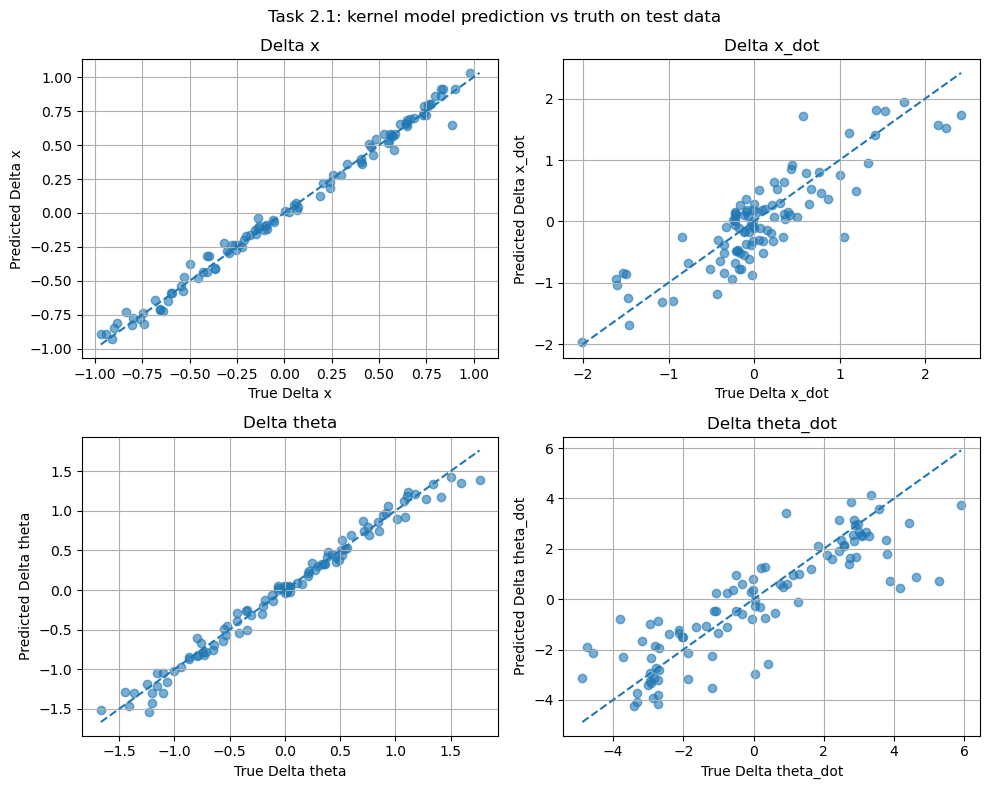

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for dim in range(4):
    ax = axes[dim]

    y_true = Y_test[:, dim]
    y_pred = Y_pred_test[:, dim]

    ax.scatter(y_true, y_pred, alpha=0.6)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        label="perfect prediction",
    )

    ax.set_xlabel(f"True {DELTA_NAMES[dim]}")
    ax.set_ylabel(f"Predicted {DELTA_NAMES[dim]}")
    ax.set_title(DELTA_NAMES[dim])
    ax.grid(True)

fig.suptitle("Task 2.1: kernel model prediction vs truth on test data")
fig.tight_layout()

save_figure(fig, "sf3_task2_1_kernel_prediction_vs_truth_test.png")
plt.show()

In [13]:
def make_linear_features(states, use_intercept=True):
    states = np.asarray(states)

    if states.ndim == 1:
        states = states[None, :]

    if use_intercept:
        ones = np.ones(states.shape[0])
        Phi = np.column_stack([states, ones])
    else:
        Phi = states.copy()

    return Phi


Phi_train = make_linear_features(X_train, use_intercept=True)
Phi_val = make_linear_features(X_val, use_intercept=True)
Phi_test = make_linear_features(X_test, use_intercept=True)

W_linear, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_train,
    Y_train,
    rcond=None,
)

Y_pred_linear_train = Phi_train @ W_linear
Y_pred_linear_val = Phi_val @ W_linear
Y_pred_linear_test = Phi_test @ W_linear

linear_train_mse = mse(Y_train, Y_pred_linear_train)
linear_val_mse = mse(Y_val, Y_pred_linear_val)
linear_test_mse = mse(Y_test, Y_pred_linear_test)

kernel_train_mse = train_mse
kernel_val_mse = val_mse
kernel_test_mse = test_mse

print("Linear model MSE:")
print("Train:", linear_train_mse)
print("Validation:", linear_val_mse)
print("Test:", linear_test_mse)

print("\nKernel model MSE:")
print("Train:", kernel_train_mse)
print("Validation:", kernel_val_mse)
print("Test:", kernel_test_mse)

Linear model MSE:
Train: 1.230413055292663
Validation: 0.7256468317024138
Test: 0.8560540630529533

Kernel model MSE:
Train: 0.37740841025508637
Validation: 0.5950966274044364
Test: 0.49546387257508356


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_linear_vs_kernel_mse.png


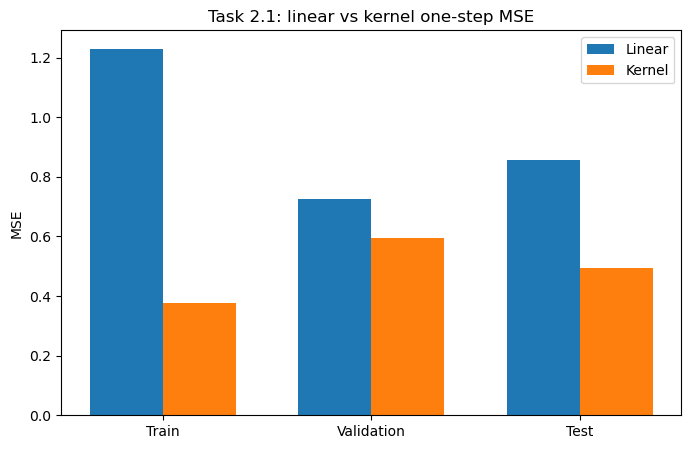

In [14]:
split_names = ["Train", "Validation", "Test"]

linear_values = [
    linear_train_mse,
    linear_val_mse,
    linear_test_mse,
]

kernel_values = [
    kernel_train_mse,
    kernel_val_mse,
    kernel_test_mse,
]

positions = np.arange(len(split_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(positions - width / 2, linear_values, width, label="Linear")
ax.bar(positions + width / 2, kernel_values, width, label="Kernel")

ax.set_xticks(positions)
ax.set_xticklabels(split_names)
ax.set_ylabel("MSE")
ax.set_title("Task 2.1: linear vs kernel one-step MSE")
ax.legend()

save_figure(fig, "sf3_task2_1_linear_vs_kernel_mse.png")
plt.show()

In [15]:
M_values = [10, 20, 40, 80, 160]
reg_strength = 1e-3

convergence_results = {}

for M_value in M_values:
    centres_M, centre_indices_M = choose_centres(X_train, M_value, seed=100 + M_value)

    alpha_M = fit_kernel_model(
        X_train=X_train,
        Y_train=Y_train,
        centres=centres_M,
        length_scales=length_scales,
        reg_strength=reg_strength,
    )

    Y_pred_train_M = predict_kernel_model(X_train, centres_M, length_scales, alpha_M)
    Y_pred_val_M = predict_kernel_model(X_val, centres_M, length_scales, alpha_M)
    Y_pred_test_M = predict_kernel_model(X_test, centres_M, length_scales, alpha_M)

    train_mse_M = mse(Y_train, Y_pred_train_M)
    val_mse_M = mse(Y_val, Y_pred_val_M)
    test_mse_M = mse(Y_test, Y_pred_test_M)

    convergence_results[M_value] = {
        "centres": centres_M,
        "alpha": alpha_M,
        "train_mse": train_mse_M,
        "val_mse": val_mse_M,
        "test_mse": test_mse_M,
    }

    print("M:", M_value)
    print("  Train MSE:", train_mse_M)
    print("  Validation MSE:", val_mse_M)
    print("  Test MSE:", test_mse_M)
    print()

M: 10
  Train MSE: 1.8122779431346232
  Validation MSE: 1.8206182394183719
  Test MSE: 1.8970183553478799

M: 20
  Train MSE: 1.2091601577722646
  Validation MSE: 1.4334392757782914
  Test MSE: 1.2971375867903014

M: 40
  Train MSE: 0.9224406448926209
  Validation MSE: 1.0785349793068832
  Test MSE: 0.8909690219033712

M: 80
  Train MSE: 0.36103499500632086
  Validation MSE: 0.477202206048315
  Test MSE: 0.4487486998006179

M: 160
  Train MSE: 0.12281383888248414
  Validation MSE: 0.563312957331865
  Test MSE: 0.4147493958712583



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_mse_vs_basis_count.png


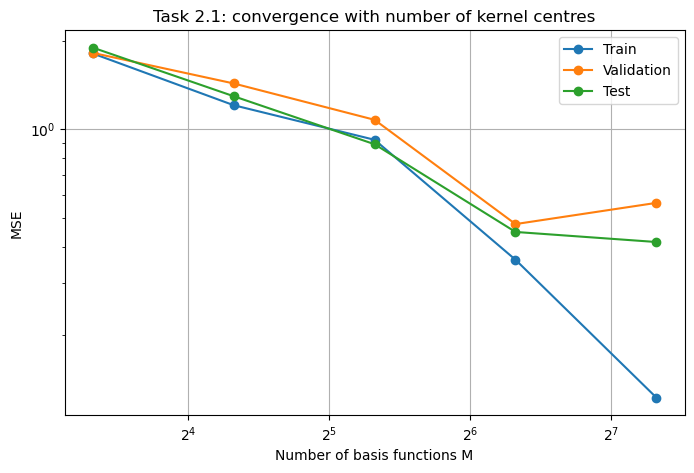

In [16]:
train_mse_values = [convergence_results[M]["train_mse"] for M in M_values]
val_mse_values = [convergence_results[M]["val_mse"] for M in M_values]
test_mse_values = [convergence_results[M]["test_mse"] for M in M_values]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(M_values, train_mse_values, marker="o", label="Train")
ax.plot(M_values, val_mse_values, marker="o", label="Validation")
ax.plot(M_values, test_mse_values, marker="o", label="Test")

ax.set_xlabel("Number of basis functions M")
ax.set_ylabel("MSE")
ax.set_title("Task 2.1: convergence with number of kernel centres")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.legend()
ax.grid(True)

save_figure(fig, "sf3_task2_1_mse_vs_basis_count.png")
plt.show()

In [17]:
train_sizes = [100, 200, 300]
M_fixed = 80
reg_strength = 1e-3

data_size_results = {}

for train_size in train_sizes:
    X_train_subset = X_train[:train_size]
    Y_train_subset = Y_train[:train_size]

    M_use = min(M_fixed, train_size)

    centres_subset, centre_indices_subset = choose_centres(
        X_train_subset,
        M_use,
        seed=200 + train_size,
    )

    length_scales_subset = np.std(X_train_subset, axis=0)
    length_scales_subset = np.maximum(length_scales_subset, 1e-6)

    alpha_subset = fit_kernel_model(
        X_train=X_train_subset,
        Y_train=Y_train_subset,
        centres=centres_subset,
        length_scales=length_scales_subset,
        reg_strength=reg_strength,
    )

    Y_pred_train_subset = predict_kernel_model(
        X_train_subset,
        centres_subset,
        length_scales_subset,
        alpha_subset,
    )

    Y_pred_val_subset = predict_kernel_model(
        X_val,
        centres_subset,
        length_scales_subset,
        alpha_subset,
    )

    train_mse_subset = mse(Y_train_subset, Y_pred_train_subset)
    val_mse_subset = mse(Y_val, Y_pred_val_subset)

    data_size_results[train_size] = {
        "train_mse": train_mse_subset,
        "val_mse": val_mse_subset,
    }

    print("Train size:", train_size)
    print("  M used:", M_use)
    print("  Train MSE:", train_mse_subset)
    print("  Validation MSE:", val_mse_subset)
    print()

Train size: 100
  M used: 80
  Train MSE: 0.07938232273310687
  Validation MSE: 0.9979278545438203

Train size: 200
  M used: 80
  Train MSE: 0.3146083667126338
  Validation MSE: 0.7624117777411056

Train size: 300
  M used: 80
  Train MSE: 0.341109226551193
  Validation MSE: 0.5503089726173543



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_mse_vs_training_size.png


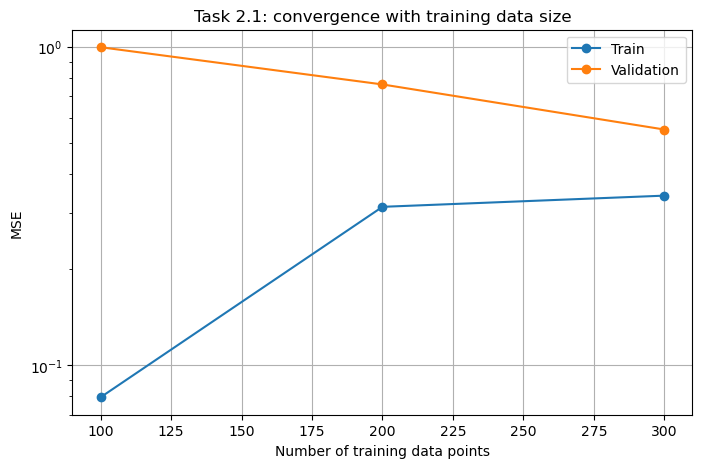

In [18]:
train_size_values = train_sizes

train_mse_size = [data_size_results[n]["train_mse"] for n in train_size_values]
val_mse_size = [data_size_results[n]["val_mse"] for n in train_size_values]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_size_values, train_mse_size, marker="o", label="Train")
ax.plot(train_size_values, val_mse_size, marker="o", label="Validation")

ax.set_xlabel("Number of training data points")
ax.set_ylabel("MSE")
ax.set_title("Task 2.1: convergence with training data size")
ax.set_yscale("log")
ax.legend()
ax.grid(True)

save_figure(fig, "sf3_task2_1_mse_vs_training_size.png")
plt.show()

In [19]:
def one_step_zero_force(initial_state):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    x0 = system.getState()
    system.performAction(0.0)
    x_next = system.getState()

    delta_x = x_next - x0

    return x0, x_next, delta_x

In [20]:
base_state = np.array([0.0, 1.0, 0.0, 0.0])

theta_values = np.linspace(-np.pi, np.pi, 61)
theta_dot_values = np.linspace(-15.0, 15.0, 61)

Theta_grid, ThetaDot_grid = np.meshgrid(theta_values, theta_dot_values)

theta_flat = Theta_grid.ravel()
theta_dot_flat = ThetaDot_grid.ravel()

X_slice = np.zeros((theta_flat.shape[0], 4))
Y_slice_true = np.zeros((theta_flat.shape[0], 4))

for i in range(theta_flat.shape[0]):
    state = base_state.copy()
    state[2] = theta_flat[i]
    state[3] = theta_dot_flat[i]

    x0, x_next, delta_x = one_step_zero_force(state)

    X_slice[i] = x0
    Y_slice_true[i] = delta_x

Y_slice_pred = predict_kernel_model(
    X_slice,
    centres,
    length_scales,
    alpha,
)

print("X_slice shape:", X_slice.shape)
print("Y_slice_true shape:", Y_slice_true.shape)
print("Y_slice_pred shape:", Y_slice_pred.shape)

X_slice shape: (3721, 4)
Y_slice_true shape: (3721, 4)
Y_slice_pred shape: (3721, 4)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_contour_true_vs_kernel_delta_thetadot.png


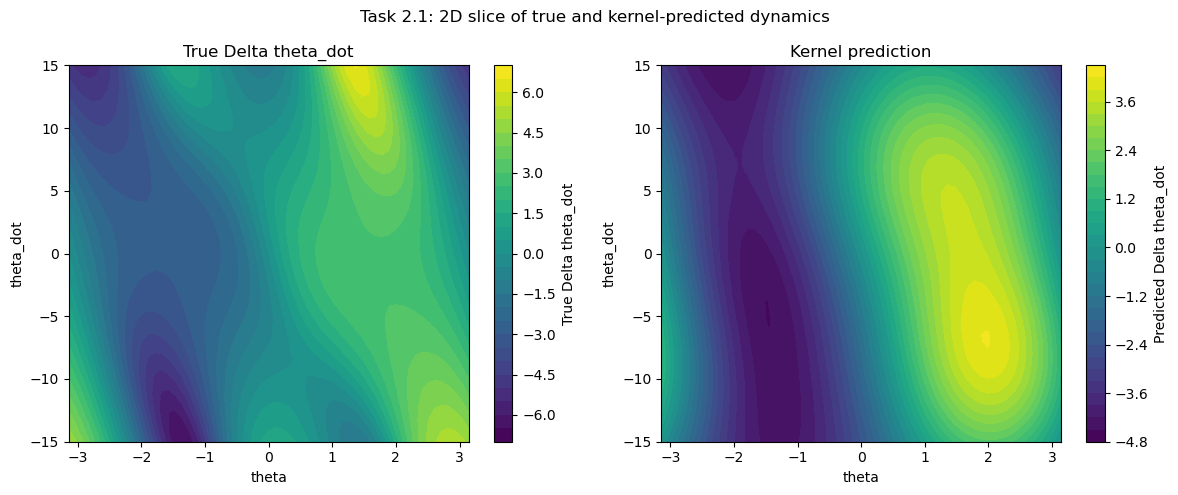

In [21]:
output_dim = 3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contour0 = axes[0].tricontourf(
    theta_flat,
    theta_dot_flat,
    Y_slice_true[:, output_dim],
    levels=30,
)

fig.colorbar(contour0, ax=axes[0], label="True Delta theta_dot")
axes[0].set_xlabel("theta")
axes[0].set_ylabel("theta_dot")
axes[0].set_title("True Delta theta_dot")

contour1 = axes[1].tricontourf(
    theta_flat,
    theta_dot_flat,
    Y_slice_pred[:, output_dim],
    levels=30,
)

fig.colorbar(contour1, ax=axes[1], label="Predicted Delta theta_dot")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("theta_dot")
axes[1].set_title("Kernel prediction")

fig.suptitle("Task 2.1: 2D slice of true and kernel-predicted dynamics")
fig.tight_layout()

save_figure(fig, "sf3_task2_1_contour_true_vs_kernel_delta_thetadot.png")
plt.show()

In [22]:
def rollout_true_zero_force(initial_state, num_steps):
    system = CartPole(visual=False)
    system.setState(np.asarray(initial_state, dtype=float))

    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = system.getState()

    for step in range(num_steps):
        system.performAction(0.0)
        trajectory[step + 1] = system.getState()

    return trajectory


def rollout_kernel_model(initial_state, num_steps, centres, length_scales, alpha, remap_theta=True):
    trajectory = np.zeros((num_steps + 1, 4))
    trajectory[0] = np.asarray(initial_state, dtype=float)

    if remap_theta:
        trajectory[0, 2] = remap_angle(trajectory[0, 2])

    for step in range(num_steps):
        current_state = trajectory[step]
        delta_pred = predict_kernel_model(
            current_state[None, :],
            centres,
            length_scales,
            alpha,
        )[0]

        next_state = current_state + delta_pred

        if remap_theta:
            next_state[2] = remap_angle(next_state[2])

        trajectory[step + 1] = next_state

    return trajectory

In [23]:
initial_state_rollout = np.array([0.0, 0.0, np.pi, 8.0])
num_steps_rollout = 80

true_traj = rollout_true_zero_force(
    initial_state_rollout,
    num_steps_rollout,
)

kernel_traj = rollout_kernel_model(
    initial_state_rollout,
    num_steps_rollout,
    centres,
    length_scales,
    alpha,
    remap_theta=True,
)

true_plot = remap_trajectory_angle(true_traj)
kernel_plot = kernel_traj.copy()

rollout_error = kernel_plot - true_plot
rollout_error_norm = np.linalg.norm(rollout_error, axis=1)

print("true_traj shape:", true_traj.shape)
print("kernel_traj shape:", kernel_traj.shape)
print("initial error:", rollout_error_norm[0])
print("error after 10 steps:", rollout_error_norm[10])
print("error after 20 steps:", rollout_error_norm[20])
print("final error:", rollout_error_norm[-1])

true_traj shape: (81, 4)
kernel_traj shape: (81, 4)
initial error: 0.0
error after 10 steps: 2.539667236287034
error after 20 steps: 1.5314356793773642
final error: 13.887911982936416


In [24]:
def plot_rollout_comparison(true_traj, model_traj, filename, title, first_n_steps=None):
    true_plot = remap_trajectory_angle(true_traj)
    model_plot = model_traj.copy()

    if first_n_steps is not None:
        true_plot = true_plot[:first_n_steps + 1]
        model_plot = model_plot[:first_n_steps + 1]
        time = np.arange(first_n_steps + 1)
    else:
        time = np.arange(true_plot.shape[0])

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    for dim in range(4):
        ax = axes[dim]

        ax.plot(time, true_plot[:, dim], label="True")
        ax.plot(time, model_plot[:, dim], linestyle="--", label="Kernel model")

        ax.set_xlabel("Time step")
        ax.set_ylabel(STATE_LABELS[dim])
        ax.set_title(STATE_NAMES[dim])
        ax.grid(True)
        ax.legend()

    fig.suptitle(title)
    fig.tight_layout()

    save_figure(fig, filename)
    plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_kernel_rollout_comparison.png


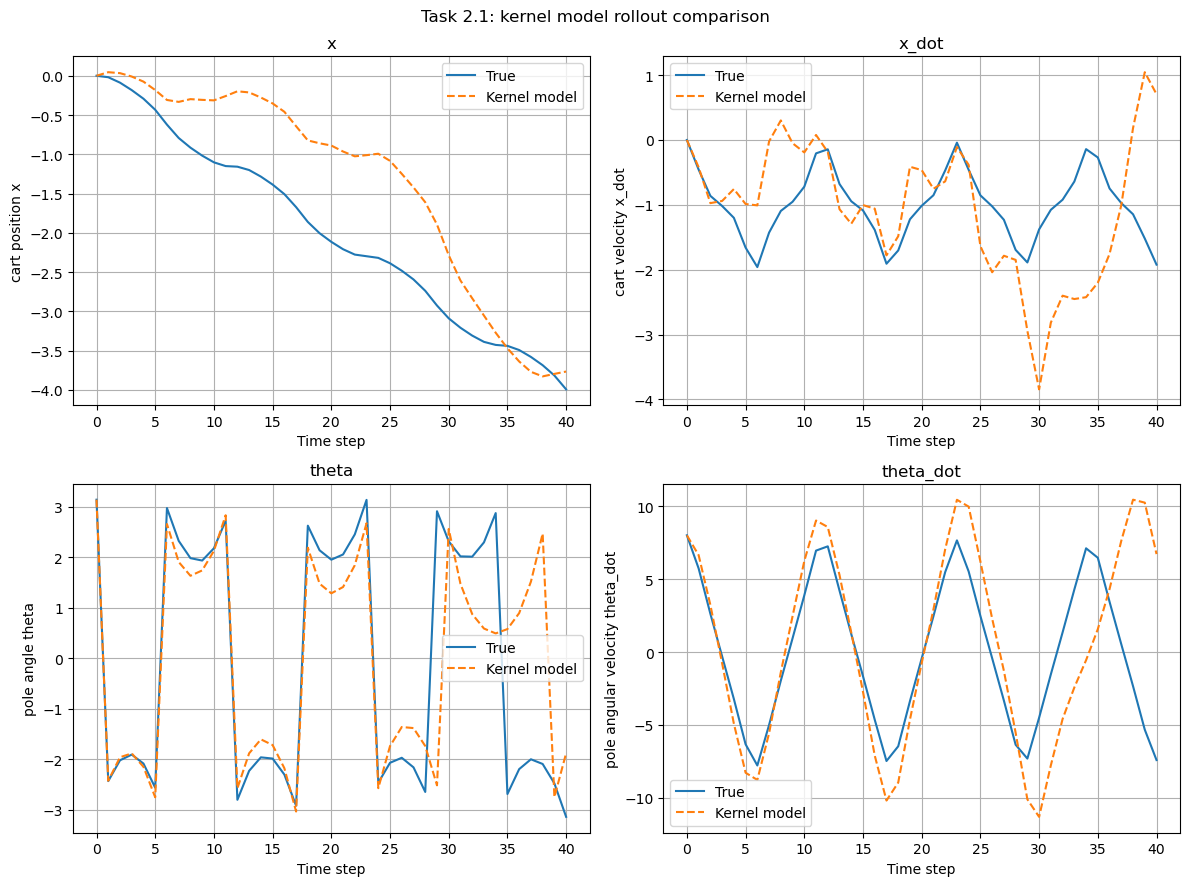

In [25]:
plot_rollout_comparison(
    true_traj=true_traj,
    model_traj=kernel_traj,
    filename="sf3_task2_1_kernel_rollout_comparison.png",
    title="Task 2.1: kernel model rollout comparison",
    first_n_steps=40,
)

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3 Machine Learning/figures/sf3_task2_1_kernel_rollout_error.png


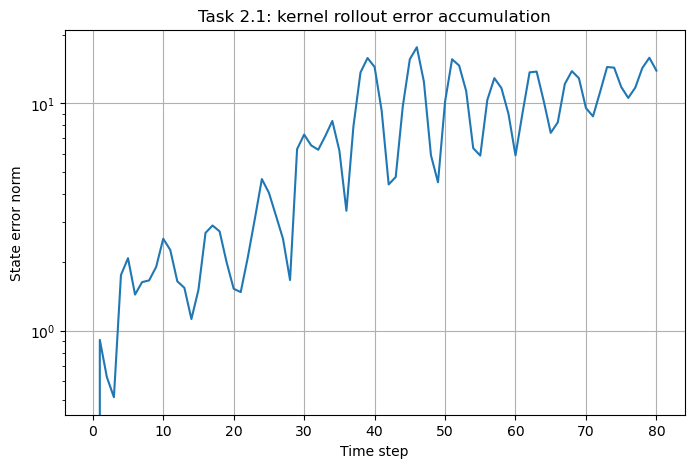

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.arange(num_steps_rollout + 1), rollout_error_norm)

ax.set_xlabel("Time step")
ax.set_ylabel("State error norm")
ax.set_title("Task 2.1: kernel rollout error accumulation")
ax.set_yscale("log")
ax.grid(True)

save_figure(fig, "sf3_task2_1_kernel_rollout_error.png")
plt.show()